# Ejercicio Python 1: Construcción de un portafolio eficiente con simulación
Evaluar la capacidad para aplicar simulaciones Monte Carlo en la construcción y análisis de portafolios con distintos niveles de riesgo y rendimiento.

Descarga precios históricos de tres activos financieros distintos El periodo de análisis debe cubrir al menos 3 años.

Calcula los rendimientos diarios y estima sus medias y matriz de covarianzas.

Simula al menos 10,000 portafolios conformados por los tres activos, con pesos aleatorios que sumen 1.

Para cada portafolio, calcula:

Rendimiento esperado.

Riesgo (desviación estándar).

Ratio de Sharpe (considera una tasa libre de riesgo de 4% anual).

Grafica el diagrama riesgo–rendimiento con todos los portafolios. En la misma figura:

Identifica el portafolio de menor riesgo.

Identifica el portafolio de mayor rendimiento.

Identifica el portafolio con mayor Sharpe.

Redacta un breve análisis, usando markdown en tu notebook, explicando qué portafolio recomendarías y por qué.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
tickers =['MSFT','AAPL','GOOG']
prices = yf.download(tickers, start='2023-01-01', end='2026-01-01')['Close']
prices

C:\Users\j_ale\AppData\Local\Temp\ipykernel_6432\2486788660.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start='2023-01-01', end='2026-01-01')['Close']
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,GOOG,MSFT
Date,,,
2023-01-03,123.096016,89.032242,233.452805
2023-01-04,124.365662,88.049614,223.240829
2023-01-05,123.046814,86.124054,216.624466
2023-01-06,127.574196,87.503723,219.177475
2023-01-09,128.095856,88.138939,221.311462
...,...,...,...
2025-12-24,273.554016,315.670013,486.908630
2025-12-26,273.144409,314.959991,486.599365
2025-12-29,273.504089,314.390015,485.990753


In [3]:
rets=prices.pct_change().dropna()
rets

Ticker,AAPL,GOOG,MSFT
Date,,,
2023-01-04,0.010314,-0.011037,-0.043743
2023-01-05,-0.010605,-0.021869,-0.029638
2023-01-06,0.036794,0.016020,0.011785
2023-01-09,0.004089,0.007259,0.009736
2023-01-10,0.004456,0.004955,0.007617
...,...,...,...
2025-12-24,0.005324,-0.000032,0.002403
2025-12-26,-0.001497,-0.002249,-0.000635
2025-12-29,0.001317,-0.001810,-0.001251


In [4]:
mean=rets.mean()
mean * 252 * 100

Ticker
AAPL    29.815231
GOOG    46.819736
MSFT    27.049629
dtype: float64

In [5]:
cov=rets.cov()
cov

Ticker,AAPL,GOOG,MSFT
Ticker,,,
AAPL,0.000260,0.000142,0.000115
GOOG,0.000142,0.000359,0.000138
MSFT,0.000115,0.000138,0.000214


C:\Users\j_ale\AppData\Local\Temp\ipykernel_6432\2814359520.py:31: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(portfolios_df.Volatility, portfolios_df.Return, cmap='viridis', alpha=0.5)


Portafolio Max Sharpe:
Pesos: {'AAPL': 0.2275771269225391, 'GOOG': 0.6007191091185307, 'MSFT': 0.17170376395893017}
Return        0.395553
Volatility    0.238497
Sharpe        1.490805
Name: 9491, dtype: float64

Portafolio Max Rendimiento:
Pesos: {'AAPL': 0.020787477140292707, 'GOOG': 0.9705261875951414, 'MSFT': 0.008686335264565876}
Return        0.462945
Volatility    0.295540
Sharpe        1.431091
Name: 9954, dtype: float64

Portafolio Mínima Volatilidad:
Pesos: {'AAPL': 0.35237655908293763, 'GOOG': 0.13554166702767437, 'MSFT': 0.512081773889388}
Return        0.307038
Volatility    0.206561
Sharpe        1.292782
Name: 3522, dtype: float64


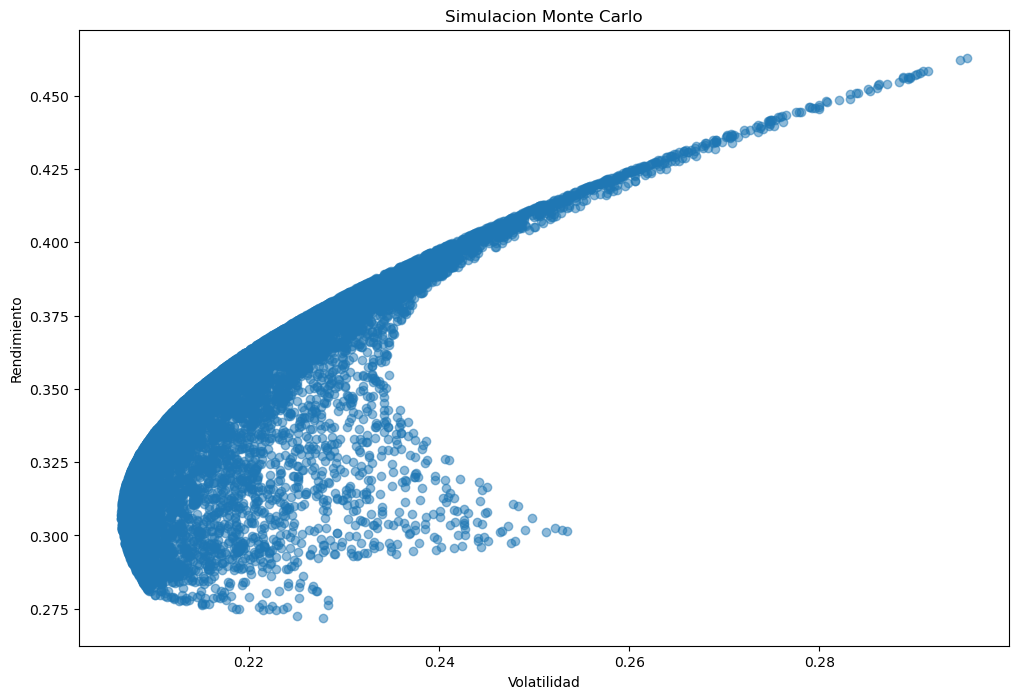

In [6]:
n_sim = 10000
risk_free_rate = 0.04
n_tickers = len(tickers)

results = np.zeros((n_tickers, n_sim))
w = []

for i in range(n_sim):
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    w.append(weights)
    
    portfolio_return = np.sum(mean * weights) * 252
    portfolio_vol = np.sqrt(weights.T @ cov @ weights) * np.sqrt(252)
    
    results[0,i] = portfolio_return
    results[1,i] = portfolio_vol
    results[2,i] = (portfolio_return - risk_free_rate) / portfolio_vol

portfolios_df = pd.DataFrame(results.T, columns=['Return', 'Volatility', 'Sharpe'])

max_sharpe_idx = portfolios_df['Sharpe'].idxmax()
min_vol_idx = portfolios_df['Volatility'].idxmin()
max_ret_idx = portfolios_df['Return'].idxmax()

max_sharpe_port = portfolios_df.iloc[max_sharpe_idx]
min_vol_port = portfolios_df.iloc[min_vol_idx]
max_ret_port = portfolios_df.iloc[max_ret_idx]

plt.figure(figsize=(12, 8))
plt.scatter(portfolios_df.Volatility, portfolios_df.Return, cmap='viridis', alpha=0.5)
plt.title('Simulacion Monte Carlo')
plt.xlabel('Volatilidad')
plt.ylabel('Rendimiento')


print("Portafolio Max Sharpe:")
print(f"Pesos: {dict(zip(prices.columns, w[max_sharpe_idx]))}")
print(max_sharpe_port)
print("\nPortafolio Max Rendimiento:")
print(f"Pesos: {dict(zip(prices.columns, w[max_ret_idx]))}")
print(max_ret_port)
print("\nPortafolio Mínima Volatilidad:")
print(f"Pesos: {dict(zip(prices.columns, w[min_vol_idx]))}")
print(min_vol_port)
